In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time

# bibliotecas do scikit-learn
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    pairwise_distances_argmin_min
)

# configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)


In [2]:
# definindo caminhos
pasta_treino_teste = '../dados/dados_processados/treino_teste/'
pasta_modelos = '../modelos/'

print("Carregando conjuntos de treino e teste\n")

# carregando atributos das 3 versões
X_train_orig = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_original.csv'))
X_test_orig = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_original.csv'))

X_train_pca = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_pca.csv'))
X_test_pca = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_pca.csv'))

X_train_lda = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_lda.csv'))
X_test_lda = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_lda.csv'))

# carregando rótulos
y_train = pd.read_csv(os.path.join(pasta_treino_teste, 'y_train.csv')).iloc[:, 0]
y_test = pd.read_csv(os.path.join(pasta_treino_teste, 'y_test.csv')).iloc[:, 0]

# carregando codificador
codificador = joblib.load(os.path.join(pasta_modelos, 'codificador_rotulos_amostrado.pkl'))

print("Dados carregados\n")
print(f" Treino: {len(y_train):,} registros | Teste: {len(y_test):,} registros")
print(f" Classes: {list(codificador.classes_)}")

print(f"\nFormatos:")
print(f"{'Versão':<12} {'X_train':<15} {'X_test':<15}")
print("=" * 45)
print(f"{'Original':<12} {str(X_train_orig.shape):<15} {str(X_test_orig.shape):<15}")
print(f"{'PCA':<12} {str(X_train_pca.shape):<15} {str(X_test_pca.shape):<15}")
print(f"{'LDA':<12} {str(X_train_lda.shape):<15} {str(X_test_lda.shape):<15}")


Carregando conjuntos de treino e teste

Dados carregados

 Treino: 7,000 registros | Teste: 3,000 registros
 Classes: ['BENIGN', 'DDoS', 'DoS Hulk', 'PortScan']

Formatos:
Versão       X_train         X_test         
Original     (7000, 78)      (3000, 78)     
PCA          (7000, 15)      (3000, 15)     
LDA          (7000, 3)       (3000, 3)      


C:\Users\William\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# o mean shift é um modelo do tipo não-supervisionado (clusterização)
# então precisamos converter os rótulos para o formato binário: 0 = normal / benign, 1 = ataque / anomalia
idx_benign = list(codificador.classes_).index('BENIGN')
print(f"Índice da classe BENIGN: {idx_benign}\n")

# criando rótulos binários
y_train_bin = (y_train != idx_benign).astype(int)
y_test_bin = (y_test != idx_benign).astype(int)

# verificando distribuição
print("Distribuição binária no treino:")
print(f"   Normal (0): {np.sum(y_train_bin==0):,} ({np.mean(y_train_bin==0)*100:.2f}%)")
print(f"   Ataque (1): {np.sum(y_train_bin==1):,} ({np.mean(y_train_bin==1)*100:.2f}%)")

print("\nDistribuição binária no teste:")
print(f"   Normal (0): {np.sum(y_test_bin==0):,} ({np.mean(y_test_bin==0)*100:.2f}%)")
print(f"   Ataque (1): {np.sum(y_test_bin==1):,} ({np.mean(y_test_bin==1)*100:.2f}%)")


Índice da classe BENIGN: 0

Distribuição binária no treino:
   Normal (0): 1,750 (25.00%)
   Ataque (1): 5,250 (75.00%)

Distribuição binária no teste:
   Normal (0): 750 (25.00%)
   Ataque (1): 2,250 (75.00%)


In [4]:
# configuração dos hiperparâmetros do mean shift
# valores escolhidos com base em boas práticas para clusterização não-supervisionada

config_ms = {
    'bandwidth': None,           # vai ser estimado automaticamente com estimate_bandwidth
    'bin_seeding': True,         # acelera o treino usando bins discretizados
    'cluster_all': True,         # faz com que todos os pontos recebam um cluster
    'n_jobs': -1,                # usa todos os cores da CPU
}

# parâmetros adicionais do experimento
SAMPLE_SIZE = 10_000             # amostragem do treino 
RANDOM_STATE = 1                 # mesma semente usada em todo projeto
QUANTILE_BW = 0.2                # quantil para estimar bandwidth, valor padrão do sklearn

print(" Configuração do Mean Shift:")
print("=" * 50)
for param, valor in config_ms.items():
    print(f"   {param:<20} = {valor}")
print(f"   {'sample_size':<20} = {SAMPLE_SIZE}")
print(f"   {'quantile_bandwidth':<20} = {QUANTILE_BW}")
print(f"   {'random_state':<20} = {RANDOM_STATE}")
print("=" * 50)


 Configuração do Mean Shift:
   bandwidth            = None
   bin_seeding          = True
   cluster_all          = True
   n_jobs               = -1
   sample_size          = 10000
   quantile_bandwidth   = 0.2
   random_state         = 1


In [5]:
# função reutilizável para treinar e avaliar um mean shift
# ela vai ser chamada 3 vezes, uma para cada versão: original, pca e lda

def treinar_e_avaliar_ms(X_train, X_test, y_train_bin, y_test_bin, nome_versao, config,
                         sample_size=SAMPLE_SIZE, quantile=QUANTILE_BW, random_state=RANDOM_STATE):
    """
    treina um mean shift e retorna as métricas e o modelo

    parâmetros:
    X_train, X_test         : conjuntos de atributos
    y_train_bin, y_test_bin : rótulos binários (0 = normal, 1 = ataque)
    nome_versao             : str, nome da versão (Original, PCA, LDA)
    config                  : dict, hiperparâmetros do modelo
    sample_size             : int, tamanho da amostra para o fit (mean shift é O(n²))
    quantile                : float, quantil usado para estimar o bandwidth
    random_state            : int, semente de aleatoriedade

    Retorna:
    --------
    dict com modelo, predições, métricas e tempos
    """
    print(f"\n{'='*60}")
    print(f"Treinando Mean Shift — Versão {nome_versao}")
    print(f"{'='*60}")
    print(f" Atributos: {X_train.shape[1]}")
    print(f" Treino:    {X_train.shape[0]:,} registros")
    print(f" Teste:     {X_test.shape[0]:,} registros")

    Xtr_arr = X_train.values if hasattr(X_train, 'values') else X_train
    Xte_arr = X_test.values if hasattr(X_test, 'values') else X_test
    ytr_arr = y_train_bin.values if hasattr(y_train_bin, 'values') else y_train_bin
    yte_arr = y_test_bin.values if hasattr(y_test_bin, 'values') else y_test_bin

    # amostragem do treino 
    rng = np.random.RandomState(random_state)
    if Xtr_arr.shape[0] > sample_size:
        idx = rng.choice(Xtr_arr.shape[0], size=sample_size, replace=False)
        Xtr_sample = Xtr_arr[idx]
        ytr_sample = ytr_arr[idx]
        print(f" Amostragem aplicada: {sample_size:,} registros")
    else:
        Xtr_sample = Xtr_arr
        ytr_sample = ytr_arr

    # estimativa do bandwidth (parâmetro crítico do mean shift)
    print(f" Estimando bandwidth (quantile={quantile})")
    inicio_bw = time.time()
    bandwidth = estimate_bandwidth(
        Xtr_sample,
        quantile=quantile,
        n_samples=2000,
        random_state=random_state
    )
    tempo_bw = time.time() - inicio_bw
    print(f" Bandwidth estimado: {bandwidth:.4f} (em {tempo_bw:.2f}s)")

    # proteção contra bandwidth zero
    if bandwidth <= 0:
        bandwidth = 1.0
        print(f" Bandwidth ajustado para {bandwidth} (valor original era 0)")

    # criando o modelo
    config_final = config.copy()
    config_final['bandwidth'] = bandwidth
    modelo = MeanShift(**config_final)

    # treinamento para medir o tempo de execução
    # mean shift não usa rótulos por ser não-supervisionado
    print(f"\n Treinando modelo")
    inicio_treino = time.time()
    modelo.fit(Xtr_sample)
    tempo_treino = time.time() - inicio_treino
    print(f" Treinamento concluído em {tempo_treino:.2f} segundos")
    print(f" Clusters encontrados: {len(np.unique(modelo.labels_))}")

    # mapeamento cluster -> classe pela maioria dos rótulos
    cluster_labels_train = modelo.labels_
    mapa_cluster_classe = {}
    for c in np.unique(cluster_labels_train):
        mask = cluster_labels_train == c
        classe_majoritaria = np.bincount(ytr_sample[mask].astype(int)).argmax()
        mapa_cluster_classe[c] = classe_majoritaria
    print(f" Mapeamento cluster→classe: {mapa_cluster_classe}")

    # predição para medir o tempo de execução
    print(f" Realizando predições")
    inicio_pred = time.time()
    cluster_pred = modelo.predict(Xte_arr)
    y_pred = np.array([mapa_cluster_classe[c] for c in cluster_pred])
    tempo_pred = time.time() - inicio_pred
    print(f" Predição concluída em {tempo_pred:.4f} segundos")

    # scores baseados na distância ao cluster mais próximo
    # quanto mais distante, maior a chance de ser anomalia/ataque
    _, dist_min = pairwise_distances_argmin_min(Xte_arr, modelo.cluster_centers_)
    scores = dist_min

    # calculando as métricas
    acuracia = accuracy_score(yte_arr, y_pred)
    precisao = precision_score(yte_arr, y_pred, zero_division=0)
    recall = recall_score(yte_arr, y_pred, zero_division=0)
    f1 = f1_score(yte_arr, y_pred, zero_division=0)
    try:
        roc_auc = roc_auc_score(yte_arr, scores)
    except Exception:
        roc_auc = np.nan

    print(f"\nMétricas:")
    print(f"   Acurácia:  {acuracia*100:.2f}%")
    print(f"   Precisão:  {precisao*100:.2f}%")
    print(f"   Recall:    {recall*100:.2f}%")
    print(f"   F1-Score:  {f1*100:.2f}%")
    print(f"   ROC-AUC:   {roc_auc*100:.2f}%")

    # retorna tudo em um dicionário
    return {
        'nome': nome_versao,
        'modelo': modelo,
        'y_pred': y_pred,
        'scores': scores,
        'bandwidth': bandwidth,
        'n_clusters': len(np.unique(modelo.labels_)),
        'mapa_cluster_classe': mapa_cluster_classe,
        'tempo_treino': tempo_treino,
        'tempo_pred': tempo_pred,
        'acuracia': acuracia,
        'precisao': precisao,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }


In [6]:
# treinando o mean shift nas 3 versões dos dados
print("Iniciando treinamento dos 3 modelos Mean Shift\n")

resultados = {}

# versão 1 com dados originais
resultados['Original'] = treinar_e_avaliar_ms(
    X_train_orig, X_test_orig, y_train_bin, y_test_bin,
    nome_versao='Original',
    config=config_ms
)

# versão 2 com dados com PCA
resultados['PCA'] = treinar_e_avaliar_ms(
    X_train_pca, X_test_pca, y_train_bin, y_test_bin,
    nome_versao='PCA',
    config=config_ms
)

# versão 3 com dados com LDA
resultados['LDA'] = treinar_e_avaliar_ms(
    X_train_lda, X_test_lda, y_train_bin, y_test_bin,
    nome_versao='LDA',
    config=config_ms
)

print(f"\n{'='*60}")
print(f"Todos os modelos foram treinados")
print(f"{'='*60}")


Iniciando treinamento dos 3 modelos Mean Shift


Treinando Mean Shift — Versão Original
 Atributos: 78
 Treino:    7,000 registros
 Teste:     3,000 registros
 Estimando bandwidth (quantile=0.2)
 Bandwidth estimado: 6.6427 (em 2.53s)

 Treinando modelo
 Treinamento concluído em 7.11 segundos
 Clusters encontrados: 15
 Mapeamento cluster→classe: {np.int64(0): np.int64(1), np.int64(1): np.int64(1), np.int64(2): np.int64(0), np.int64(3): np.int64(1), np.int64(4): np.int64(0), np.int64(5): np.int64(0), np.int64(6): np.int64(0), np.int64(7): np.int64(0), np.int64(8): np.int64(1), np.int64(9): np.int64(0), np.int64(10): np.int64(0), np.int64(11): np.int64(0), np.int64(12): np.int64(0), np.int64(13): np.int64(1), np.int64(14): np.int64(0)}
 Realizando predições
 Predição concluída em 0.0033 segundos

Métricas:
   Acurácia:  76.37%
   Precisão:  76.06%
   Recall:    99.96%
   F1-Score:  86.38%
   ROC-AUC:   48.30%

Treinando Mean Shift — Versão PCA
 Atributos: 15
 Treino:    7,000 registros
 T

grafico salvo em: ../figuras/roc_mean_shift.png


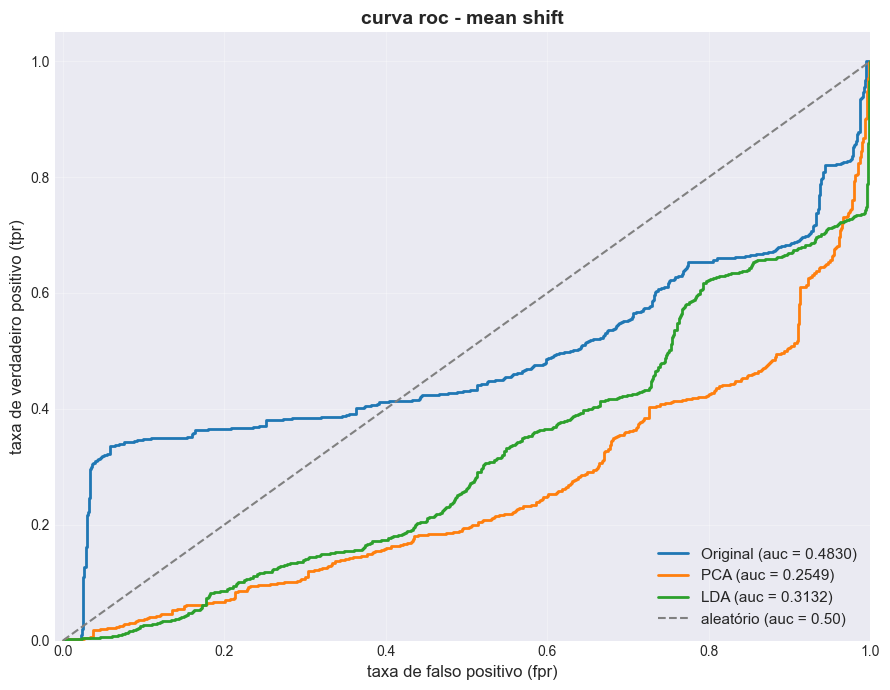

In [7]:
# gerando a curva roc para cada versão dos dados
plt.figure(figsize=(9, 7))

cores = {'Original': '#1f77b4', 'PCA': '#ff7f0e', 'LDA': '#2ca02c'}

for nome_versao, res in resultados.items():
    # roc_curve retorna fpr, tpr e thresholds
    fpr, tpr, _ = roc_curve(y_test_bin, res['scores'])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(
        fpr, tpr,
        color=cores[nome_versao],
        lw=2,
        label=f"{nome_versao} (auc = {roc_auc:.4f})"
    )

# linha diagonal de referência (classificador aleatório)
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='aleatório (auc = 0.50)')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('taxa de falso positivo (fpr)', fontsize=12)
plt.ylabel('taxa de verdadeiro positivo (tpr)', fontsize=12)
plt.title('curva roc - mean shift', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# salvando o gráfico
pasta_figuras = '../figuras/'
os.makedirs(pasta_figuras, exist_ok=True)
caminho_fig = os.path.join(pasta_figuras, 'roc_mean_shift.png')
plt.savefig(caminho_fig, dpi=150, bbox_inches='tight')
print(f"grafico salvo em: {caminho_fig}")

plt.show()


In [8]:
# criando tabela comparativa com todas as métricas
print("TABELA COMPARATIVA — Mean Shift nas 3 versões\n")

# construindo dataframe com os resultados
df_comparacao = pd.DataFrame({
    'Versão': [r['nome'] for r in resultados.values()],
    'Atributos': [
        X_train_orig.shape[1],
        X_train_pca.shape[1],
        X_train_lda.shape[1]
    ],
    'N Clusters': [r['n_clusters'] for r in resultados.values()],
    'Acurácia (%)': [r['acuracia']*100 for r in resultados.values()],
    'Precisão (%)': [r['precisao']*100 for r in resultados.values()],
    'Recall (%)': [r['recall']*100 for r in resultados.values()],
    'F1-Score (%)': [r['f1']*100 for r in resultados.values()],
    'ROC-AUC (%)': [r['roc_auc']*100 for r in resultados.values()],
    'Tempo Treino (s)': [r['tempo_treino'] for r in resultados.values()],
    'Tempo Pred. (s)': [r['tempo_pred'] for r in resultados.values()]
})

# formatando para exibição
df_comparacao_formatado = df_comparacao.copy()
for col in ['Acurácia (%)', 'Precisão (%)', 'Recall (%)', 'F1-Score (%)', 'ROC-AUC (%)']:
    df_comparacao_formatado[col] = df_comparacao_formatado[col].apply(lambda x: f"{x:.2f}")
df_comparacao_formatado['Tempo Treino (s)'] = df_comparacao_formatado['Tempo Treino (s)'].apply(lambda x: f"{x:.2f}")
df_comparacao_formatado['Tempo Pred. (s)'] = df_comparacao_formatado['Tempo Pred. (s)'].apply(lambda x: f"{x:.4f}")

print(df_comparacao_formatado.to_string(index=False))

# identificando o melhor modelo por F1-Score
melhor_versao = df_comparacao.loc[df_comparacao['F1-Score (%)'].idxmax(), 'Versão']
print(f"\nMelhor versão (por F1-Score): {melhor_versao}")


TABELA COMPARATIVA — Mean Shift nas 3 versões

  Versão  Atributos  N Clusters Acurácia (%) Precisão (%) Recall (%) F1-Score (%) ROC-AUC (%) Tempo Treino (s) Tempo Pred. (s)
Original         78          15        76.37        76.06      99.96        86.38       48.30             7.11          0.0033
     PCA         15          22        76.50        76.16      99.96        86.45       25.49             0.98          0.0022
     LDA          3          30        96.90        96.59      99.38        97.96       31.32             0.78          0.0021

Melhor versão (por F1-Score): LDA


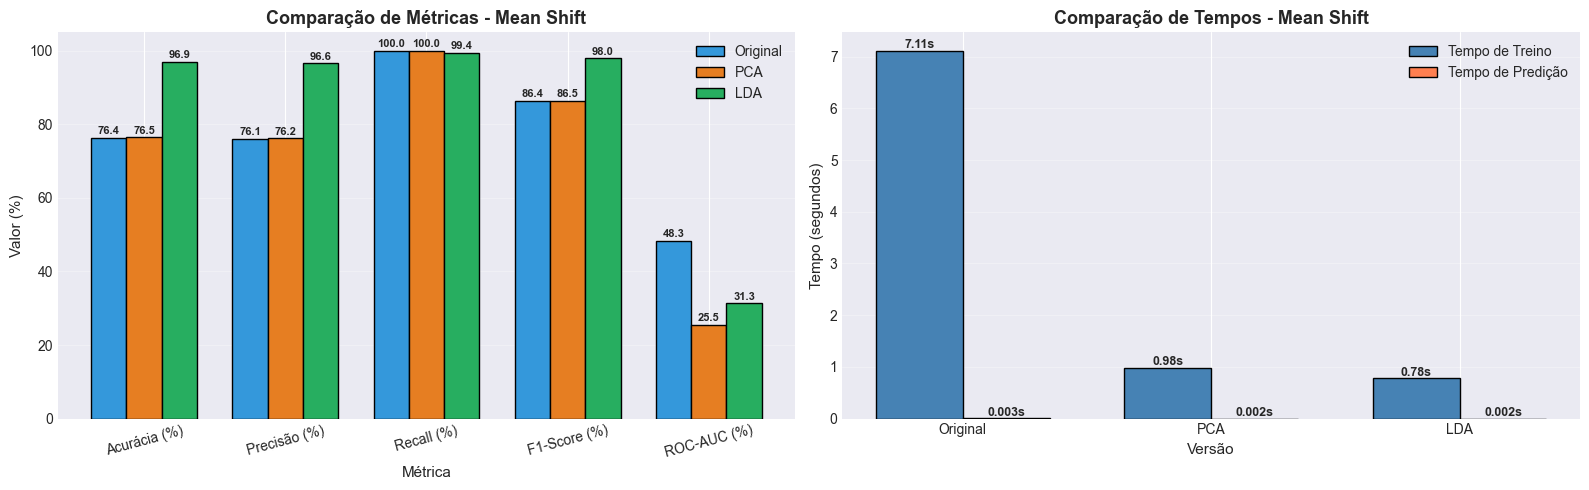

In [9]:
# visualização comparativa em gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# gráfico das métricas de classificação
metricas = ['Acurácia (%)', 'Precisão (%)', 'Recall (%)', 'F1-Score (%)', 'ROC-AUC (%)']
versoes = ['Original', 'PCA', 'LDA']
cores = ['#3498db', '#e67e22', '#27ae60']

x_pos = np.arange(len(metricas))
largura = 0.25

for i, versao in enumerate(versoes):
    valores = [df_comparacao.loc[df_comparacao['Versão'] == versao, m].values[0] for m in metricas]
    axes[0].bar(x_pos + i*largura, valores, largura, label=versao, color=cores[i], edgecolor='black')

axes[0].set_xlabel('Métrica', fontsize=11)
axes[0].set_ylabel('Valor (%)', fontsize=11)
axes[0].set_title('Comparação de Métricas - Mean Shift', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos + largura)
axes[0].set_xticklabels(metricas, rotation=15)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 105])

# adicionando valores nas barras
for i, versao in enumerate(versoes):
    valores = [df_comparacao.loc[df_comparacao['Versão'] == versao, m].values[0] for m in metricas]
    for j, v in enumerate(valores):
        axes[0].text(x_pos[j] + i*largura, v + 1, f'{v:.1f}',
                     ha='center', fontsize=8, fontweight='bold')

# gráfico dos tempos de execução
tempos_treino = df_comparacao['Tempo Treino (s)'].values
tempos_pred = df_comparacao['Tempo Pred. (s)'].values

x_pos2 = np.arange(len(versoes))
largura2 = 0.35

axes[1].bar(x_pos2 - largura2/2, tempos_treino, largura2,
            label='Tempo de Treino', color='steelblue', edgecolor='black')
axes[1].bar(x_pos2 + largura2/2, tempos_pred, largura2,
            label='Tempo de Predição', color='coral', edgecolor='black')

axes[1].set_xlabel('Versão', fontsize=11)
axes[1].set_ylabel('Tempo (segundos)', fontsize=11)
axes[1].set_title('Comparação de Tempos - Mean Shift', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos2)
axes[1].set_xticklabels(versoes)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# adicionando valores
for i, (t, p) in enumerate(zip(tempos_treino, tempos_pred)):
    axes[1].text(i - largura2/2, t + 0.05, f'{t:.2f}s', ha='center', fontweight='bold', fontsize=9)
    axes[1].text(i + largura2/2, p + 0.05, f'{p:.3f}s', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


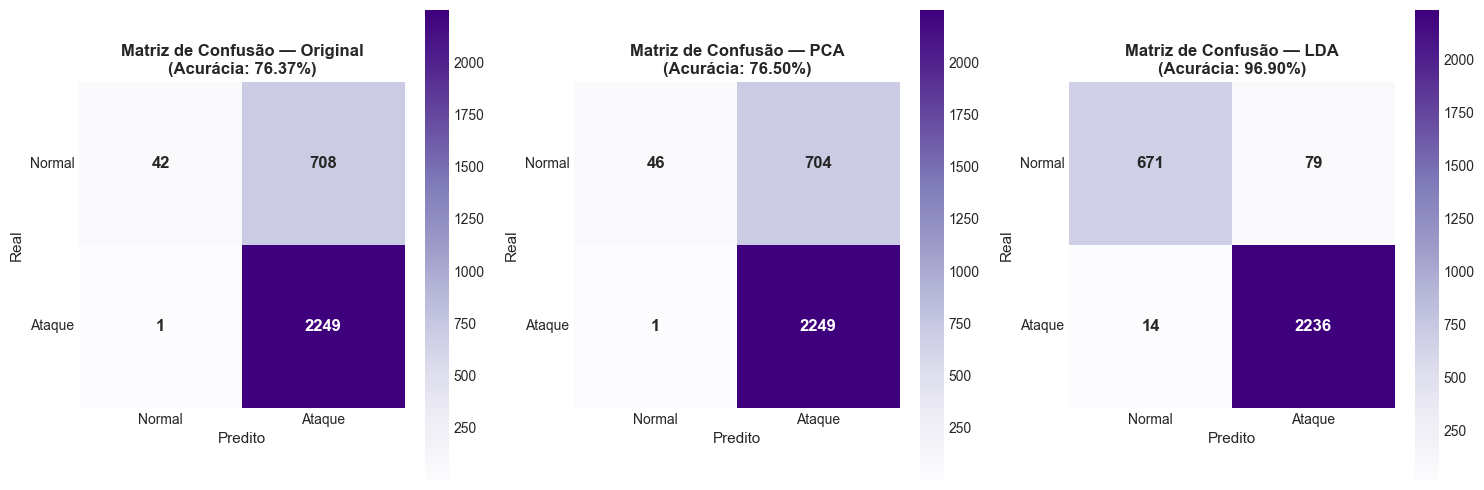

  Diagonal principal = acertos
  Fora da diagonal   = erros
  Linha = classe real | Coluna = classe de previsão


In [10]:
# mostrando as 3 matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nomes_classes_bin = ['Normal', 'Ataque']

for idx, (versao, dados) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test_bin, dados['y_pred'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=nomes_classes_bin, yticklabels=nomes_classes_bin,
                ax=axes[idx], cbar=True, square=True,
                annot_kws={'fontsize': 12, 'fontweight': 'bold'})

    axes[idx].set_xlabel('Predito', fontsize=11)
    axes[idx].set_ylabel('Real', fontsize=11)
    axes[idx].set_title(f'Matriz de Confusão — {versao}\n(Acurácia: {dados["acuracia"]*100:.2f}%)',
                        fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=0)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print("  Diagonal principal = acertos")
print("  Fora da diagonal   = erros")
print("  Linha = classe real | Coluna = classe de previsão")


In [11]:
# mostrando o relatório de classificação completo para cada versão
nomes_classes_bin = ['Normal', 'Ataque']

for versao, dados in resultados.items():
    print(f"\n{'='*65}")
    print(f"Relatório de classificação — Mean Shift ({versao})")
    print(f"{'='*65}")
    print(classification_report(
        y_test_bin, dados['y_pred'],
        target_names=nomes_classes_bin,
        digits=4
    ))



Relatório de classificação — Mean Shift (Original)
              precision    recall  f1-score   support

      Normal     0.9767    0.0560    0.1059       750
      Ataque     0.7606    0.9996    0.8638      2250

    accuracy                         0.7637      3000
   macro avg     0.8687    0.5278    0.4849      3000
weighted avg     0.8146    0.7637    0.6744      3000


Relatório de classificação — Mean Shift (PCA)
              precision    recall  f1-score   support

      Normal     0.9787    0.0613    0.1154       750
      Ataque     0.7616    0.9996    0.8645      2250

    accuracy                         0.7650      3000
   macro avg     0.8702    0.5304    0.4900      3000
weighted avg     0.8159    0.7650    0.6772      3000


Relatório de classificação — Mean Shift (LDA)
              precision    recall  f1-score   support

      Normal     0.9796    0.8947    0.9352       750
      Ataque     0.9659    0.9938    0.9796      2250

    accuracy                        

In [12]:
# salvando os 3 modelos treinados e as métricas
print("Salvando modelos e métricas\n")

# caminhos para salvar os modelos
caminhos_modelos = {
    'Original': os.path.join(pasta_modelos, 'modelo_ms_original.pkl'),
    'PCA': os.path.join(pasta_modelos, 'modelo_ms_pca.pkl'),
    'LDA': os.path.join(pasta_modelos, 'modelo_ms_lda.pkl')
}

# salvando cada modelo
for versao, caminho in caminhos_modelos.items():
    joblib.dump(resultados[versao]['modelo'], caminho)
    tamanho_mb = os.path.getsize(caminho) / (1024 * 1024)
    print(f"  Modelo mean shift {versao}: {caminho} ({tamanho_mb:.2f} MB)")

# salvando métricas num arquivo csv para análise em proximas etapas
pasta_resultados = '../resultados/metricas/'
os.makedirs(pasta_resultados, exist_ok=True)

caminho_metricas = os.path.join(pasta_resultados, 'metricas_mean_shift.csv')
df_comparacao.to_csv(caminho_metricas, index=False)
print(f"\n Métricas salvas: {caminho_metricas}")


Salvando modelos e métricas

  Modelo mean shift Original: ../modelos/modelo_ms_original.pkl (0.06 MB)
  Modelo mean shift PCA: ../modelos/modelo_ms_pca.pkl (0.06 MB)
  Modelo mean shift LDA: ../modelos/modelo_ms_lda.pkl (0.05 MB)

 Métricas salvas: ../resultados/metricas/metricas_mean_shift.csv


In [13]:
# resumo
print("\n" + "="*65)
print("RESUMO FINAL — Mean Shift")
print("="*65)

print(f"\nModelos treinados: 3 (Original, PCA, LDA)")
print(f"\nRanking por F1-Score:")
ranking = df_comparacao.sort_values('F1-Score (%)', ascending=False)
for i, (_, row) in enumerate(ranking.iterrows(), 1):
    print(f"   {i}º — {row['Versão']:<10} F1: {row['F1-Score (%)']:.2f}%  |  Acc: {row['Acurácia (%)']:.2f}%  |  ROC-AUC: {row['ROC-AUC (%)']:.2f}%")

print(f"\nEficiência:")
mais_rapido_treino = df_comparacao.loc[df_comparacao['Tempo Treino (s)'].idxmin(), 'Versão']
mais_rapido_pred = df_comparacao.loc[df_comparacao['Tempo Pred. (s)'].idxmin(), 'Versão']
print(f"  Treinamento mais rápido:  {mais_rapido_treino}")
print(f"  Predição mais rápida:     {mais_rapido_pred}")



RESUMO FINAL — Mean Shift

Modelos treinados: 3 (Original, PCA, LDA)

Ranking por F1-Score:
   1º — LDA        F1: 97.96%  |  Acc: 96.90%  |  ROC-AUC: 31.32%
   2º — PCA        F1: 86.45%  |  Acc: 76.50%  |  ROC-AUC: 25.49%
   3º — Original   F1: 86.38%  |  Acc: 76.37%  |  ROC-AUC: 48.30%

Eficiência:
  Treinamento mais rápido:  LDA
  Predição mais rápida:     LDA
